In [ ]:
import pandas as pd

# Load dataset
iris_df = pd.read_csv('Iris.csv')

# Display the first 5 rows of the dataset
print('First 5 rows of the Iris dataset:')
print(iris_df.head())

# Display basic information about the dataset
print('\nInformation about the Iris dataset:')
iris_df.info()

# Display descriptive statistics
print('\nDescriptive statistics of the Iris dataset:')
print(iris_df.describe())

First 5 rows of the Iris dataset:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Information about the Iris dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: flo

### Data Preparation and Feature Engineering

**Justification for dropping 'Id' column:**
The 'Id' column is a unique identifier for each sample and does not contain any predictive information relevant to the species classification. Including it would add noise and potentially confuse the model without contributing to its learning. Therefore, it's good practice to remove it.

In [ ]:
# Drop the 'Id' column as it is not a feature for classification
iris_df = iris_df.drop('Id', axis=1)

print("DataFrame after dropping 'Id' column:")
print(iris_df.head())

DataFrame after dropping 'Id' column:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa


**Justification for Label Encoding 'Species' column:**
Machine learning algorithms typically require numerical input. The 'Species' column is a categorical variable with string values ('Iris-setosa', 'Iris-versicolor', 'Iris-virginica'). Label Encoding converts these categorical labels into numerical values (e.g., 0, 1, 2), making them suitable for model training. Since 'Species' is the target variable, one-hot encoding is not necessary here, and label encoding is simpler.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to the 'Species' column
iris_df['Species_encoded'] = le.fit_transform(iris_df['Species'])

# Display the mapping of original species to encoded values
print("Species mapping:")
for i, species in enumerate(le.classes_):
    print(f"{species}: {i}")

print("\nDataFrame after Label Encoding 'Species' column:")
print(iris_df.head())
print(iris_df['Species_encoded'].value_counts())

Species mapping:
Iris-setosa: 0
Iris-versicolor: 1
Iris-virginica: 2

DataFrame after Label Encoding 'Species' column:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species  \
0            5.1           3.5            1.4           0.2  Iris-setosa   
1            4.9           3.0            1.4           0.2  Iris-setosa   
2            4.7           3.2            1.3           0.2  Iris-setosa   
3            4.6           3.1            1.5           0.2  Iris-setosa   
4            5.0           3.6            1.4           0.2  Iris-setosa   

   Species_encoded  
0                0  
1                0  
2                0  
3                0  
4                0  
Species_encoded
0    50
1    50
2    50
Name: count, dtype: int64


**Justification for creating new features (Sepal/Petal Area and Ratios):**
Creating new features from existing ones, also known as feature engineering, can often help machine learning models capture more complex relationships in the data. For the Iris dataset, combining length and width into an 'area' feature (e.g., `SepalArea` = `SepalLengthCm` * `SepalWidthCm`) might provide a better representation of the overall size of the sepal or petal than individual length or width measurements alone. Similarly, ratios like `SepalLengthToWidthRatio` can highlight the shape or proportion, which might be a distinguishing characteristic between species.

In [ ]:
# Feature Engineering

# Sepal Area
iris_df['SepalArea'] = iris_df['SepalLengthCm'] * iris_df['SepalWidthCm']

# Petal Area
iris_df['PetalArea'] = iris_df['PetalLengthCm'] * iris_df['PetalWidthCm']

# Sepal Length to Width Ratio
iris_df['SepalLengthToWidthRatio'] = iris_df['SepalLengthCm'] / iris_df['SepalWidthCm']

# Petal Length to Width Ratio
iris_df['PetalLengthToWidthRatio'] = iris_df['PetalLengthCm'] / iris_df['PetalWidthCm']

print("\nDataFrame after creating new features:")
print(iris_df.head())

print("\nDescriptive statistics of new features:")
print(iris_df[['SepalArea', 'PetalArea', 'SepalLengthToWidthRatio', 'PetalLengthToWidthRatio']].describe())


DataFrame after creating new features:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species  \
0            5.1           3.5            1.4           0.2  Iris-setosa   
1            4.9           3.0            1.4           0.2  Iris-setosa   
2            4.7           3.2            1.3           0.2  Iris-setosa   
3            4.6           3.1            1.5           0.2  Iris-setosa   
4            5.0           3.6            1.4           0.2  Iris-setosa   

   Species_encoded  SepalArea  PetalArea  SepalLengthToWidthRatio  \
0                0      17.85       0.28                 1.457143   
1                0      14.70       0.28                 1.633333   
2                0      15.04       0.26                 1.468750   
3                0      14.26       0.30                 1.483871   
4                0      18.00       0.28                 1.388889   

   PetalLengthToWidthRatio  
0                      7.0  
1                      7.0  
2

### Data Splitting for Model Training

**Justification for splitting data into Features (X) and Target (y):**
In supervised machine learning, we need to clearly define which columns are used as input to predict the output. The features (X) are the independent variables that the model will learn from, while the target (y) is the dependent variable (in our case, the `Species_encoded`) that the model aims to predict. This separation is fundamental for model training.

**Justification for splitting data into Training and Testing sets:**
It is a standard practice in machine learning to divide the dataset into training and testing sets. The training set is used to teach the model, allowing it to learn the underlying patterns and relationships in the data. The testing set, which the model has never seen before, is then used to evaluate the model's performance and generalization ability. This prevents overfitting (where a model performs well on training data but poorly on new data) and provides an unbiased estimate of the model's predictive power. A typical split is 70-80% for training and 20-30% for testing.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = iris_df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
             'SepalArea', 'PetalArea', 'SepalLengthToWidthRatio', 'PetalLengthToWidthRatio']]
y = iris_df['Species_encoded']

# Split the data into training and testing sets
# We'll use a test size of 30% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (105, 8)
Shape of X_test: (45, 8)
Shape of y_train: (105,)
Shape of y_test: (45,)


**FEATURE SCALING**

Transforms all feature values so they have a mean of 0 and a standard deviation of 1.

Neural Network and Logistic Regression are both sensitive to the scale of input values.

Features like SepalArea can be 10–30 while SepalWidthcm is around 2–4 — without scaling, the larger values would dominate unfairly and skew the model's learning.

`fit_transform `on the training data only, then transform (not fit) on the test data. This is to prevent data leakage — meaning the model should have absolutely no knowledge of the test set during training. If we fit the scaler on the full dataset including test data, the model indirectly "sees" the test data, which gives artificially good results.

Decision Tree does not need scaling because it makes decisions using thresholds ("if PetalLength > 2.5"), not distances. The actual size of the values does not affect how the tree splits.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled  = scaler.transform(X_test)       # apply same scale to test

**TRAIN 3 MODELS**

Trains three different classification models on the training data and evaluates each on the test data.

Decision Tree — plits data into branches using if-else rules. Easy to interpret and visualise. Does not require feature scaling.


Neural Network (MLP) — passes data through 2 hidden layers of 100 and 50 neurons. Each neuron learns a pattern from the data and passes signals forward until a prediction is made. `max_iter=500` means it trains for up to 500 rounds to find the best weights.

Logistic Regression — a statistical model that calculates the probability of each species and assigns the class with the highest probability. Despite the name, it is a classification model, not regression. It draws a straight decision boundary between classes, making it simple but effective for linearly separable data. Requires scaled data

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

class_names = le.classes_

# Model 1: Decision Tree
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc  = accuracy_score(y_test, dt_pred)


print("  MODEL 1: Decision Tree")
print(f"  Accuracy : {dt_acc * 100:.2f}%")
print(classification_report(y_test, dt_pred, target_names=class_names))

#  Model 2: Neural Network

nn_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
nn_model.fit(X_train_scaled, y_train)
nn_pred = nn_model.predict(X_test_scaled)
nn_acc  = accuracy_score(y_test, nn_pred)


print("  MODEL 2: Neural Network (MLP)")
print(f"  Accuracy : {nn_acc * 100:.2f}%")
print(classification_report(y_test, nn_pred, target_names=class_names))

# Model 3: Logistic Regression
lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_acc  = accuracy_score(y_test, lr_pred)


print("  MODEL 3: Logistic Refression")
print(f"  Accuracy : {lr_acc * 100:.2f}%")
print(classification_report(y_test, lr_pred, target_names=class_names))


  MODEL 1: Decision Tree
  Accuracy : 88.89%
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.78      0.93      0.85        15
 Iris-virginica       0.92      0.73      0.81        15

       accuracy                           0.89        45
      macro avg       0.90      0.89      0.89        45
   weighted avg       0.90      0.89      0.89        45

  MODEL 2: Neural Network (MLP)
  Accuracy : 91.11%
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.82      0.93      0.88        15
 Iris-virginica       0.92      0.80      0.86        15

       accuracy                           0.91        45
      macro avg       0.92      0.91      0.91        45
   weighted avg       0.92      0.91      0.91        45

  MODEL 3: Logistic Refression
  Accuracy : 91.11%
                 precision    recall  f1-score  

**COMPARISON TABLE**

Puts all model results — Accuracy, Precision, Recall, F1-Score — into one table sorted from best to worst.

Accuracy — out of all predictions, how many were correct

Precision — of all the times we predicted a species, how often were we right

Recall — of all the actual flowers of a species, how many did we correctly catch

F1-Score — the balance between precision and recall (useful when classes are unequal)

In [ ]:
import pandas as pd

dt_report  = classification_report(y_test, dt_pred,  target_names=class_names, output_dict=True)
nn_report  = classification_report(y_test, nn_pred,  target_names=class_names, output_dict=True)
lr_report = classification_report(y_test, lr_pred, target_names=class_names, output_dict=True)

comparison_df = pd.DataFrame({
    'Decision Tree': {
        'Accuracy (%)' : round(dt_acc  * 100, 2),
        'Precision (%)': round(dt_report ['macro avg']['precision'] * 100, 2),
        'Recall (%)'   : round(dt_report ['macro avg']['recall']    * 100, 2),
        'F1-Score (%)'  : round(dt_report ['macro avg']['f1-score']  * 100, 2),
    },
    'Neural Network': {
        'Accuracy (%)' : round(nn_acc * 100, 2),
        'Precision (%)': round(nn_report['macro avg']['precision'] * 100, 2),
        'Recall (%)'   : round(nn_report['macro avg']['recall']    * 100, 2),
        'F1-Score (%)'  : round(nn_report['macro avg']['f1-score']  * 100, 2),
    },
    'Logistic Regression': {
        'Accuracy (%)' : round(lr_acc * 100, 2),
        'Precision (%)': round(lr_report['macro avg']['precision'] * 100, 2),
        'Recall (%)'   : round(lr_report['macro avg']['recall']    * 100, 2),
        'F1-Score (%)'  : round(lr_report['macro avg']['f1-score']  * 100, 2),
    },
}).T.sort_values('Accuracy (%)', ascending=False)


print("       FINAL MODEL COMPARISON")
print(comparison_df.to_string())

best_model = comparison_df.index[0]
best_acc   = comparison_df.loc[best_model, 'Accuracy (%)']

print(f"\n BEST MODEL : {best_model}")
print(f"   Accuracy   : {best_acc:.2f}%")
print(f"\nCONCLUSION:")
print(f"   {best_model} achieves the highest accuracy of {best_acc:.2f}% ")



       FINAL MODEL COMPARISON
                     Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
Neural Network              91.11          91.55       91.11         91.07
Logistic Regression         91.11          91.55       91.11         91.07
Decision Tree               88.89          89.81       88.89         88.78

 BEST MODEL : Neural Network
   Accuracy   : 91.11%

CONCLUSION:
   Neural Network achieves the highest accuracy of 91.11% 


**VISUALIZATION**

Why: Visuals make it easier to explain and understand model behaviour.

Confusion matrices — shows exactly which species were predicted correctly or mixed up for each model

Accuracy bar chart — quick visual comparison of the 3 models

F1-Score grouped bar — shows per-species performance for each model

Engineered feature scatter — plots the full dataset using the new PetalArea and Petal Ratio features to show species separation

Best model predictions — same scatter but coloured by what the best model predicted, with misclassified points circled in black

Feature importance — shows which of the 8 features the Decision Tree relied on most




/tmp/ipykernel_4809/993059187.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


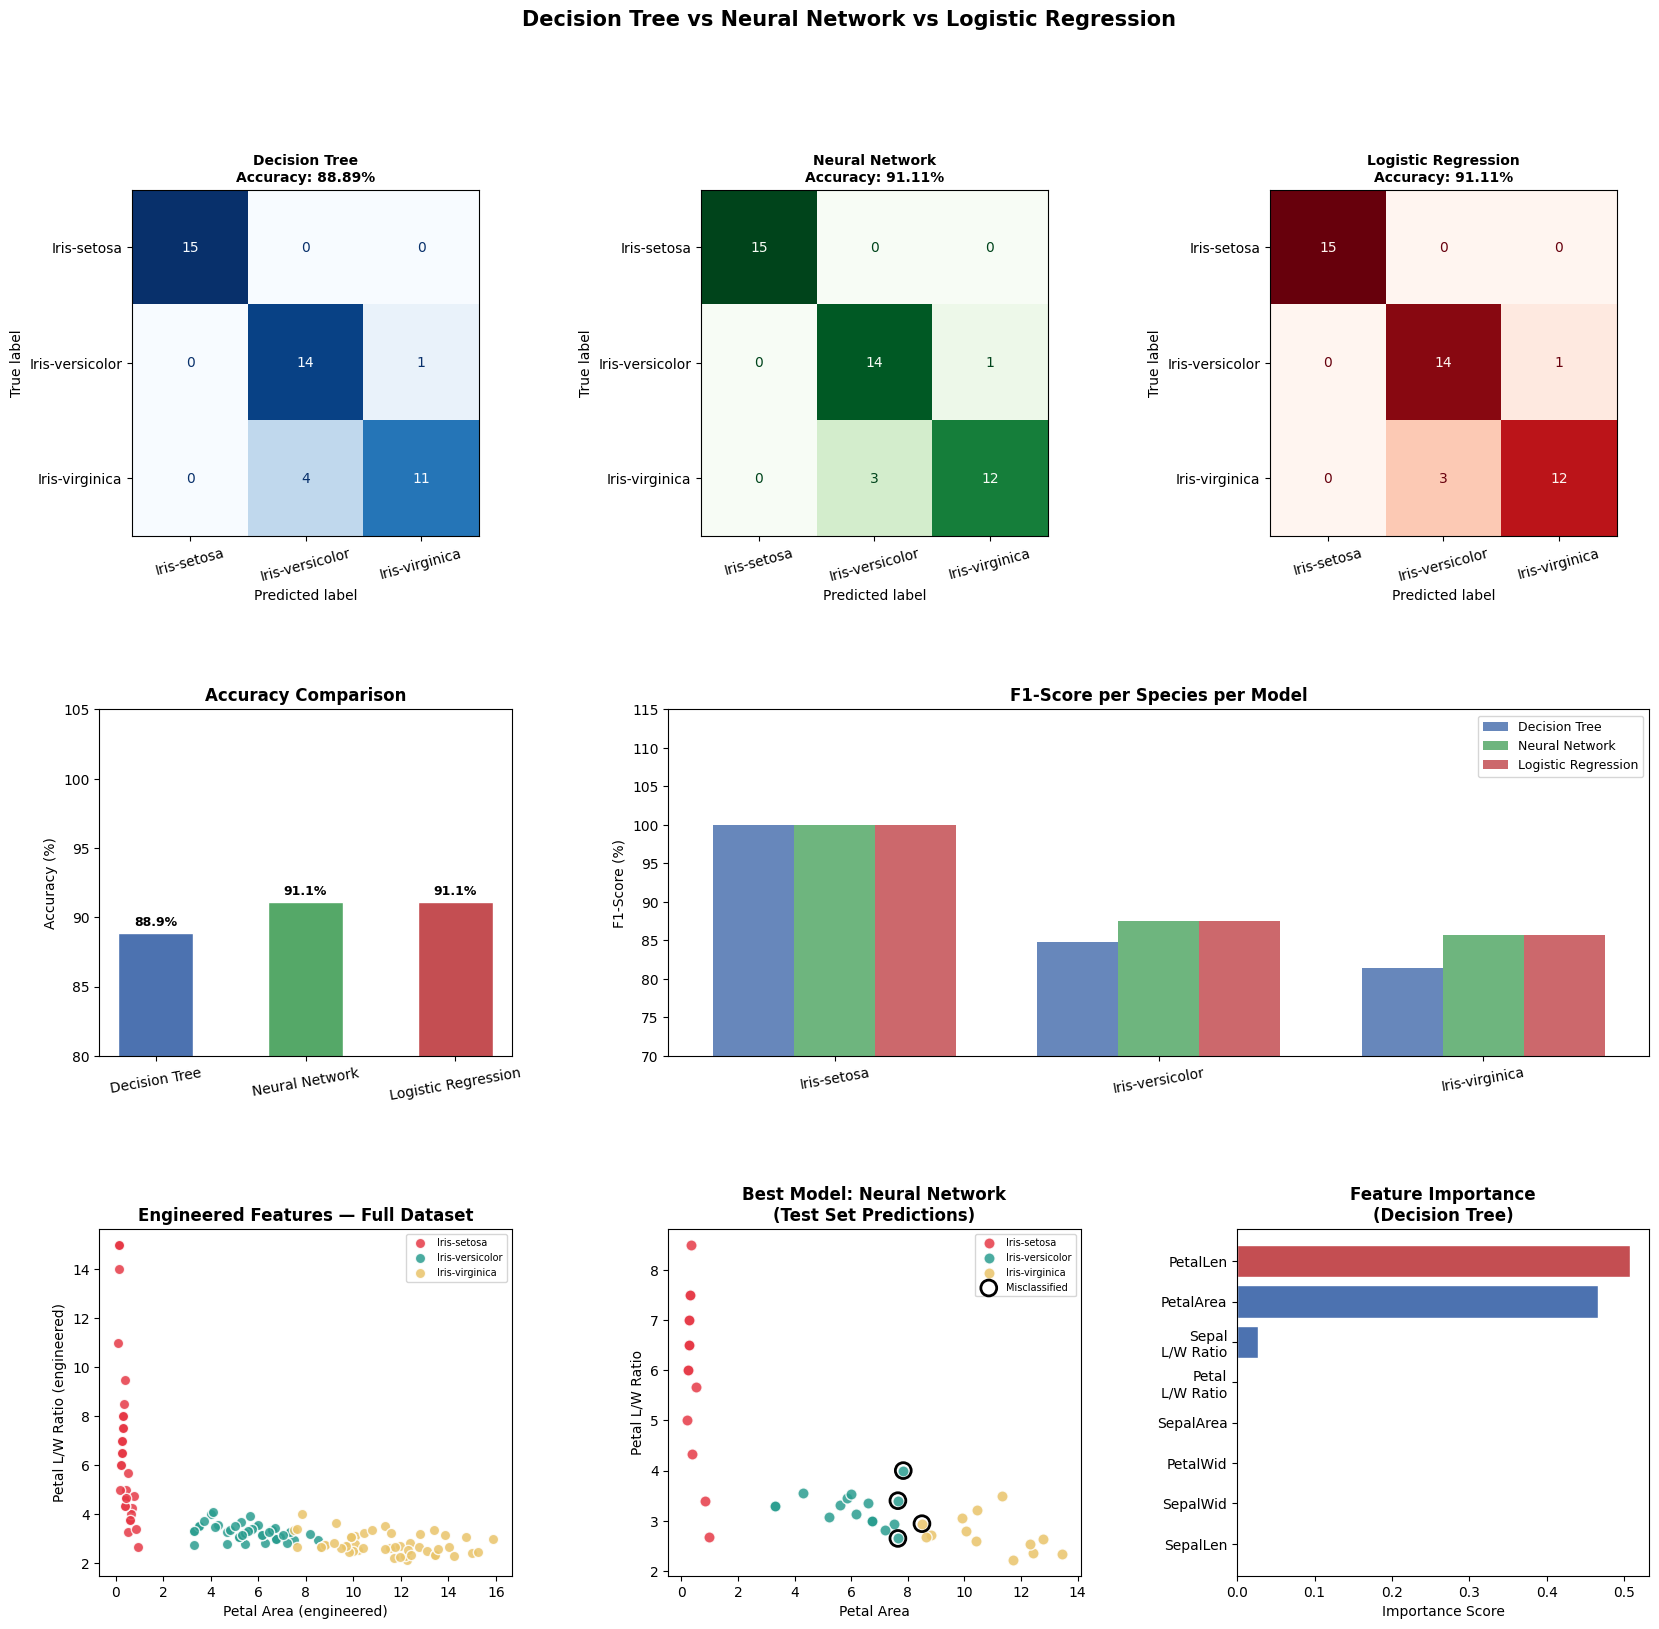

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import ConfusionMatrixDisplay

fig = plt.figure(figsize=(20, 18))
fig.suptitle(
    "Decision Tree vs Neural Network vs Logistic Regression",
    fontsize=15, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

model_names = ['Decision Tree', 'Neural Network', 'Logistic Regression']
preds       = [dt_pred, nn_pred, lr_pred]
accs        = [dt_acc,  nn_acc,  lr_acc]
cmaps       = ['Blues', 'Greens', 'Reds']
palette     = ['#4C72B0', '#55A868', '#C44E52']


for i in range(3):
    ax = fig.add_subplot(gs[0, i])
    cm = confusion_matrix(y_test, preds[i])
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, colorbar=False, cmap=cmaps[i]
    )
    ax.set_title(f"{model_names[i]}\nAccuracy: {accs[i]*100:.2f}%",
                 fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)


ax_bar = fig.add_subplot(gs[1, 0])
bars = ax_bar.bar(model_names, [a * 100 for a in accs],
                  color=palette, edgecolor='white', width=0.5)
ax_bar.set_ylim(80, 105)
ax_bar.set_ylabel("Accuracy (%)")
ax_bar.set_title("Accuracy Comparison", fontweight='bold')
ax_bar.tick_params(axis='x', rotation=10)
for bar, acc in zip(bars, accs):
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{acc*100:.1f}%", ha='center', fontweight='bold', fontsize=9)


ax_f1 = fig.add_subplot(gs[1, 1:])
x = np.arange(len(class_names))
w = 0.25
for i, (name, report) in enumerate(zip(model_names, [dt_report, nn_report, lr_report])):
    f1s = [report[c]['f1-score'] * 100 for c in class_names]
    ax_f1.bar(x + i * w, f1s, w, label=name, color=palette[i], alpha=0.85)
ax_f1.set_xticks(x + w)
ax_f1.set_xticklabels(class_names, rotation=10)
ax_f1.set_ylim(70, 115)
ax_f1.set_ylabel("F1-Score (%)")
ax_f1.set_title("F1-Score per Species per Model", fontweight='bold')
ax_f1.legend(fontsize=9)


ax_eng = fig.add_subplot(gs[2, 0])
species_colors = ['#e63946', '#2a9d8f', '#e9c46a']
for cls_idx, cls_name in enumerate(class_names):
    mask = iris_df['Species_encoded'] == cls_idx
    ax_eng.scatter(
        iris_df.loc[mask, 'PetalArea'],
        iris_df.loc[mask, 'PetalLengthToWidthRatio'],
        c=species_colors[cls_idx], label=cls_name, edgecolors='white', s=55, alpha=0.85
    )
ax_eng.set_xlabel("Petal Area (engineered)")
ax_eng.set_ylabel("Petal L/W Ratio (engineered)")
ax_eng.set_title("Engineered Features — Full Dataset", fontweight='bold')
ax_eng.legend(fontsize=7)


best_pred = preds[model_names.index(best_model)]
ax_pred = fig.add_subplot(gs[2, 1])
X_test_reset = X_test.reset_index(drop=True)
for cls_idx, cls_name in enumerate(class_names):
    mask = best_pred == cls_idx
    ax_pred.scatter(
        X_test_reset.loc[mask, 'PetalArea'],
        X_test_reset.loc[mask, 'PetalLengthToWidthRatio'],
        c=species_colors[cls_idx], label=cls_name, edgecolors='white', s=65, alpha=0.85
    )
wrong = best_pred != y_test.values
ax_pred.scatter(
    X_test_reset.loc[wrong, 'PetalArea'],
    X_test_reset.loc[wrong, 'PetalLengthToWidthRatio'],
    facecolors='none', edgecolors='black', s=130, linewidth=2, label='Misclassified'
)
ax_pred.set_xlabel("Petal Area")
ax_pred.set_ylabel("Petal L/W Ratio")
ax_pred.set_title(f"Best Model: {best_model}\n(Test Set Predictions)", fontweight='bold')
ax_pred.legend(fontsize=7)


ax_feat = fig.add_subplot(gs[2, 2])
feat_labels = ['SepalLen', 'SepalWid', 'PetalLen', 'PetalWid',
               'SepalArea', 'PetalArea', 'Sepal\nL/W Ratio', 'Petal\nL/W Ratio']
importances = dt_model.feature_importances_
sorted_idx  = np.argsort(importances)
bar_colors_f = ['#C44E52' if i == sorted_idx[-1] else '#4C72B0' for i in range(len(importances))]
ax_feat.barh(
    [feat_labels[i] for i in sorted_idx],
    importances[sorted_idx],
    color=[bar_colors_f[i] for i in sorted_idx],
    edgecolor='white'
)
ax_feat.set_xlabel("Importance Score")
ax_feat.set_title("Feature Importance\n(Decision Tree)", fontweight='bold')

plt.tight_layout()
plt.show()
